zaczytanie niezbędnych bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from sklearn.preprocessing import StandardScaler

zaczytaj dane dotyczace sprzedazy

In [26]:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Salary Data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "rkiattisak/salaly-prediction-for-beginer",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

<ipython-input-26-72cc2aa30810>:9: DeprecationWarning: load_dataset is deprecated and will be removed in future version.
  df = kagglehub.load_dataset(


First 5 records:     Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


preprocessing

1.   sprawdż typy danych
2.   zmien etykiedy na zmienne liczbowe
3. w przypadku brakujacych danych uzupelnij (w przypadku etykiet) najczesciej wystepującą wartością lub średnią wartością



In [27]:
# 1 - sprawdzanie wymiarów i typów kolumn
wiersze, kolumny = df.shape
print(f"Wiersze: {wiersze}\nKolumny {kolumny}")

df.info()


Wiersze: 375
Kolumny 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [28]:
# 2 - zmiana etykiet na zmienne liczbowe
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
columns_to_trasform = ['Gender', 'Education Level', 'Job Title']
for col in columns_to_trasform:
  df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,1,0,159,5.0,90000.0
1,28.0,0,1,17,3.0,65000.0
2,45.0,1,2,130,15.0,150000.0
3,36.0,0,0,101,7.0,60000.0
4,52.0,1,1,22,20.0,200000.0


In [29]:
# zastąpienie wartości pustych średnią
for col in df.columns:
  mean = df[col].mean()
  df[col].fillna(mean, inplace = True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  375 non-null    float64
 1   Gender               375 non-null    int64  
 2   Education Level      375 non-null    int64  
 3   Job Title            375 non-null    int64  
 4   Years of Experience  375 non-null    float64
 5   Salary               375 non-null    float64
dtypes: float64(3), int64(3)
memory usage: 17.7 KB


<ipython-input-29-275af4349b67>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mean, inplace = True)


Podziel zbiór danych na testowy i treningowy w stosunku 30/70

In [30]:
# wybór zmiennych objaśniających i zmiennej objaśnianej
X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Stworz model regresji liniowej korzystajac z parametrów domyślnych
Przykład dokumentacji: https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols.html#sphx-glr-auto-examples-linear-model-plot-ols-py

In [31]:
# stworzenie modelu regresji liniowej
from collections.abc import AsyncGenerator
from sklearn.linear_model import LinearRegression

regressor = LinearRegression().fit(X_train, y_train)

coef = regressor.coef_
b = regressor.intercept_

age = coef[0]
gender = coef[1]
edu = coef[2]
job = coef[3]
years = coef[4]
print(f"Model ma postać: Y = age*{age} + gedner*{gender} + education*{edu} + job title*{job} + experience*{years} + {b}")

Model ma postać: Y = age*3090.2685883689683 + gedner*5958.354933959703 + education*13947.6862611479 + job title*25.61874870350357 + experience*2682.38650755487 + -55541.45692757191


ocen model na zbiorze testowym za pomocą miar: średni błąd kwadratowy, średni błąd absolutny, wynik wyjaśnionej wariancji

In [32]:
# ocena jakości modelu
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}\nMAE = {mae}\nR2 = {r2}")

MSE: 251384617.98392048
MAE = 10976.816634914625
R2 = 0.8821304345871546


spróbuj poprawić model, zacznij od danych, sprawdz korelacje, znormalizuj

In [33]:
# Macierz korelacji
cor_matrix = df.corr()
cor_matrix

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
Age,1.000000,-0.019865,0.546020,0.116616,0.979128,0.922335
Gender,-0.019865,1.000000,0.008677,0.041562,0.002818,0.069498
Education Level,0.546020,0.008677,1.000000,0.127791,0.573355,0.650507
Job Title,0.116616,0.041562,0.127791,1.000000,0.099299,0.135033
Years of Experience,0.979128,0.002818,0.573355,0.099299,1.000000,0.930338
Salary,0.922335,0.069498,0.650507,0.135033,0.930338,1.000000


<Axes: >

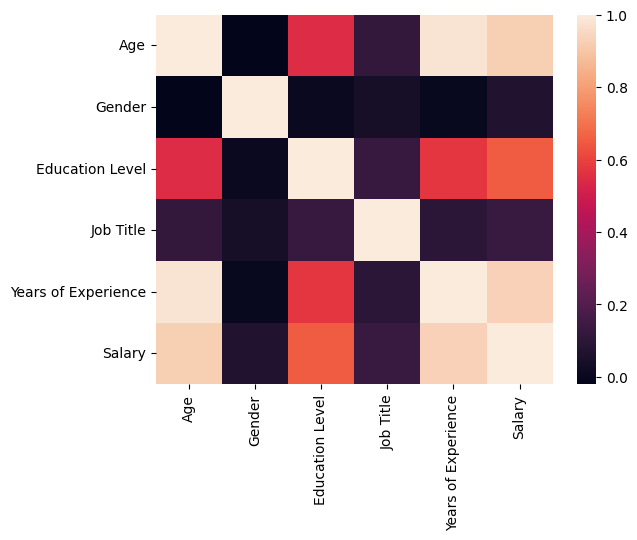

In [34]:
#heatmapa korelacji
import seaborn as sns
sns.heatmap(cor_matrix)

In [35]:
# normalizacja danych
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

for col in df.columns:
  df[col] = scaler.fit_transform(df[[col]])

df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,0.300000,0.5,0.000000,0.913793,0.20,0.359103
1,0.166667,0.0,0.333333,0.097701,0.12,0.258963
2,0.733333,0.5,0.666667,0.747126,0.60,0.599439
3,0.433333,0.0,0.000000,0.580460,0.28,0.238935
4,0.966667,0.5,0.333333,0.126437,0.80,0.799720


In [36]:
# Nowa macierz korelacji
cor_matrix = df.corr()
cor_matrix

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
Age,1.000000,-0.019865,0.546020,0.116616,0.979128,0.922335
Gender,-0.019865,1.000000,0.008677,0.041562,0.002818,0.069498
Education Level,0.546020,0.008677,1.000000,0.127791,0.573355,0.650507
Job Title,0.116616,0.041562,0.127791,1.000000,0.099299,0.135033
Years of Experience,0.979128,0.002818,0.573355,0.099299,1.000000,0.930338
Salary,0.922335,0.069498,0.650507,0.135033,0.930338,1.000000


In [37]:
# Usunięcie zmiennej 'Age' w związku z jej silną korelacją ze zmienną 'Years of Experience' oraz stworzenie nowego modelu
df.drop('Age', axis=1, inplace = True)

X = df.drop('Salary', axis=1)
y = df['Salary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

regressor = LinearRegression().fit(X_train, y_train)

coef = regressor.coef_
b = regressor.intercept_

gender = coef[0]
edu = coef[1]
job = coef[2]
years = coef[3]
print(f"Model ma postać: Y = gedner*{gender} + education*{edu} + job title*{job} + experience*{years} + {b}")

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}\nMAE = {mae}\nR2 = {r2}")


Model ma postać: Y = gedner*0.038987374254165624 + education*0.15831596164145792 + job title*0.02497506765605234 + experience*0.6024610956790275 + 0.10617671796583383
MSE: 0.0039586031432073164
MAE = 0.044228036161353
R2 = 0.8843173874193462


In [38]:
# nowa macierz korelacji
cor_matrix_2 = df.corr()
cor_matrix_2

,Gender,Education Level,Job Title,Years of Experience,Salary
Gender,1.000000,0.008677,0.041562,0.002818,0.069498
Education Level,0.008677,1.000000,0.127791,0.573355,0.650507
Job Title,0.041562,0.127791,1.000000,0.099299,0.135033
Years of Experience,0.002818,0.573355,0.099299,1.000000,0.930338
Salary,0.069498,0.650507,0.135033,0.930338,1.000000


<Axes: >

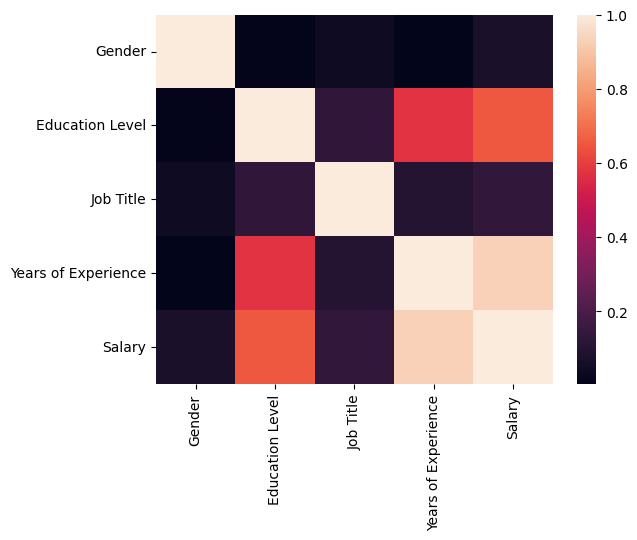

In [39]:
sns.heatmap(cor_matrix_2)

Zbuduj model regresji odpornej i przetestuj jego predykcje

In [40]:
# Regresja opdorna - regresja Hubera
from sklearn.linear_model import HuberRegressor

huber_model = HuberRegressor()

huber_model.fit(X_train, y_train)

y_pred_huber = huber_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred_huber)
mae = mean_absolute_error(y_test, y_pred_huber)
r2 = r2_score(y_test, y_pred_huber)

print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'R^2: {r2}')


MSE: 0.0038402191197084057
MAE: 0.04383359333500594
R^2: 0.887776934292506


Wykreś przewidziane i faktyczne wartości obu modeli (przykład w dokumentacji: https://scikit-learn.org/stable/auto_examples/ensemble/plot_voting_regressor.html#sphx-glr-auto-examples-ensemble-plot-voting-regressor-py)

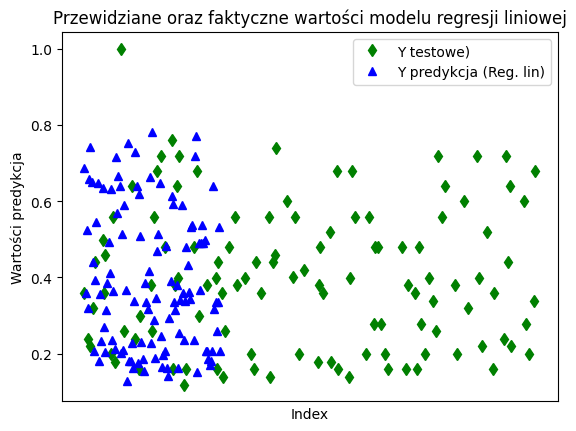

In [41]:
# Wizualizacja dla modelu regresji liniowej
plt.figure()
plt.plot(y_test, "gd", label="Y testowe)")
plt.plot(y_pred, "b^", label="Y predykcja (Reg. lin)")

plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
plt.ylabel("Wartości predykcja")
plt.xlabel("Index")
plt.legend(loc="best")
plt.title("Przewidziane oraz faktyczne wartości modelu regresji liniowej")
plt.show()

plt.show()



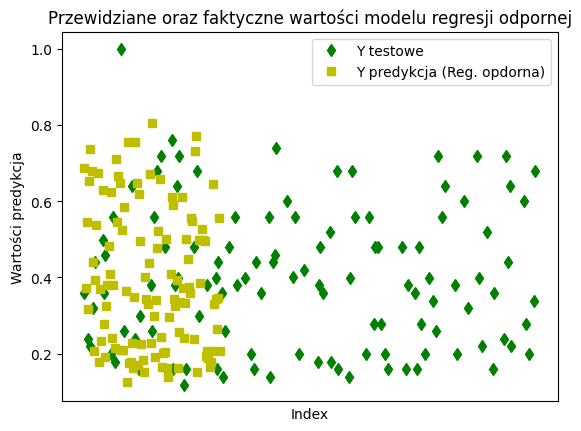

In [42]:
# Wizualizacja dla modelu Regresji Hubera
plt.figure()
plt.plot(y_test, "gd", label="Y testowe")
plt.plot(y_pred_huber, "ys", label="Y predykcja (Reg. opdorna)")

plt.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
plt.ylabel("Wartości predykcja")
plt.xlabel("Index")
plt.legend(loc="best")
plt.title("Przewidziane oraz faktyczne wartości modelu regresji odpornej")
plt.show()

plt.show()

In [43]:
y_pred, y_pred_huber

(array([0.68608599, 0.35921809, 0.52402011, 0.32033295, 0.65753797,
        0.74158775, 0.64911709, 0.43966525, 0.20743904, 0.39320242,
        0.54423413, 0.64652182, 0.1809005 , 0.35748403, 0.23196809,
        0.63329599, 0.26898467, 0.20543088, 0.31402379, 0.38472222,
        0.49372905, 0.41111722, 0.63099943, 0.23614224, 0.36424181,
        0.21175673, 0.71662809, 0.57018254, 0.66544403, 0.64061887,
        0.20100702, 0.51512999, 0.2101662 , 0.58898619, 0.36693931,
        0.1271251 , 0.75378821, 0.18018283, 0.18147464, 0.22881032,
        0.1634163 , 0.33783516, 0.72899271, 0.64047534, 0.17602032,
        0.61882602, 0.50935893, 0.23154652, 0.18549362, 0.15580895,
        0.38603205, 0.33424679, 0.31776734, 0.41674474, 0.66399964,
        0.22909739, 0.78064347, 0.28936285, 0.18909363, 0.34499389,
        0.4702344 , 0.51383817, 0.64694605, 0.24616262, 0.16442105,
        0.19769408, 0.20643429, 0.48156462, 0.1634163 , 0.1408851 ,
        0.29479012, 0.3902062 , 0.6138023 , 0.59

Zmodyfikuj kod, zeby zwizualizować wynik lepszego z modeli

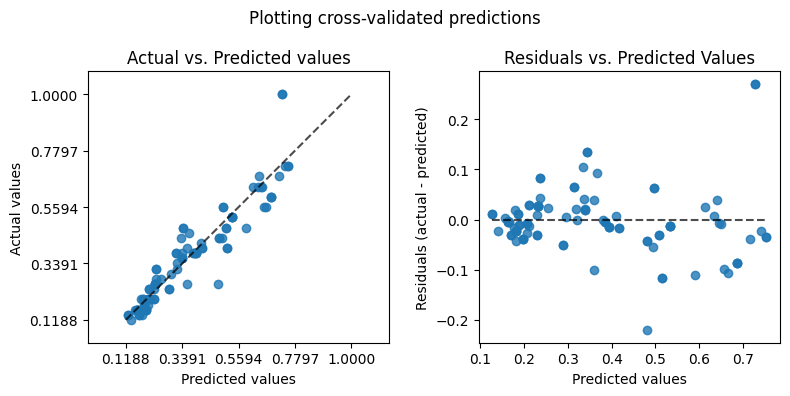

In [45]:
import matplotlib.pyplot as plt

from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=100,
    ax=axs[0],
    random_state=0,
)
axs[0].set_title("Actual vs. Predicted values")
PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred,
    kind="residual_vs_predicted",
    subsample=100,
    ax=axs[1],
    random_state=0,
)
axs[1].set_title("Residuals vs. Predicted Values")
fig.suptitle("Plotting cross-validated predictions")
plt.tight_layout()
plt.show()